# Two Uncertain Inputs: Ply Thickness Joins Fiber Strength

NB2 and NB3 carried a single uncertain input, the longitudinal tensile strength $X_T$,
through the single-shell0element model and read a design-relevant percentile off the resulting
distribution of peak force $F_{peak}$. NB2 sized its sample size $N$ analytically because
$F_{peak}=A\cdot X_T$ is an exactly linear map; NB3 threw that shortcut away and monitored a
bootstrap confidence interval instead, converging each campaign on its own criterion.

This notebook adds a **second** uncertain input: the ply thickness $t$. In the small-strain
limit the peak force is

$$F_{peak} = w\,t\,X_T,$$

with $w=10$ mm the gauge width and $t$ the ply thickness (NB1's geometry; $A=w\,t$ was the
constant cross-section in NB2). Making $t$ random as well as $X_T$ turns this into a product
of two random variables.

**No Abaqus runs at all.** This notebook asks the question about what a second uncertain parameter does to the output distribution, and through what mechanism. To simplify our investigation, we deliberately choose to explore the answer to this question using only the small-strain linear formula, without running any Abaqus simulations. We do this because the answer is **not** about the Abaqus model, but about the mathematics of how uncertainty of multiple input parameters propagates through a map, in this case a product of two random variables.

**Learning objectives**

- Understand what changes when a model has more than one uncertain input: **marginal** vs.
  **joint** distributions, **covariance**/**correlation** as the measure of whether two inputs
  scatter together, and the role of an **independence** assumption.
- Derive, from first principles, the one thing about the output that *can* still be computed
  exactly with two random inputs: its coefficient of variation.
- See why the number of Monte Carlo samples a percentile needs is set by the **scatter** the
  inputs put into the output, not simply by how many inputs there are, via the asymptotic standard
  error of a sample quantile.
- Run NB3's exact bootstrap convergence criterion on three cases, $\mathrm{CoV}_t\in\{0,\ 2\%,\ 5\%\}$, and watch the required $N$ track the output's spread rather than the input count.
- Compare the three converged output distributions, with bootstrap confidence intervals on
  both the mean and $Q_{5\%}$, and read what a second uncertain input does to the mean, the
  spread, and the low-percentile design value.

**Notation.** $\mathrm{CoV}_t=\sigma_t/\mu_t$ and $\mathrm{CoV}_{X_T}=\sigma_{X_T}/\mu_{X_T}$
are the coefficients of variation of the two *inputs*; $\mathrm{CoV}_F$ is the coefficient of
variation of the *output* $F_{peak}$. Units throughout, as in the rest of the series:
**mm / N / MPa** ($1$ MPa $=1$ N/mm$^2$).

## Part 1 &ndash; What it means to have more than one uncertain input

### Marginal and joint distributions

With one uncertain input, "the distribution of $X_T$" was the whole story. With two, each
input still has its own distribution, called its **marginal distribution**, and in this notebook we take both marginals to be Normal:

$$t \sim \mathcal{N}\!\big(t_0,\ \mathrm{CoV}_t\cdot t_0\big), \qquad
X_T \sim \mathcal{N}(990\ \text{MPa},\ 49.5\ \text{MPa}),$$

with $t_0 = 0.20$ mm the nominal ply thickness from NB1's geometry and $X_T$'s marginal
exactly the same distribution from NB2 ($\mathrm{CoV}_{X_T}=5\%$). We leave $\mathrm{CoV}_t$
unfixed for now, since Part 3 sweeps it over several values. The pair $(t, X_T)$ is described
by a **joint** distribution $f(t, x)$ over the whole plane, and the two marginals on their own
do **not** pin it down: they say how each input scatters, but nothing about whether the two
scatter *together*.

### Covariance, correlation, and independence

"Scattering together" has a name and a number. The **covariance** of $t$ and $X_T$ is the
average, over many draws, of the product of their two deviations from their own means,

$$\mathrm{cov}(t, X_T) = \mathrm{E}\big[(t-\mu_t)(X_T-\mu_X)\big].$$

Read it one draw at a time: if a pair has both values above their means, both deviations are
positive and the product is positive; if both are below, both deviations are negative and the
product is positive again; if one is above while the other is below, the product is negative.
Averaged over the whole sample, a positive covariance means the two tend to run high together
and low together, a negative one means one running high goes with the other running low, and a
covariance near zero means there is no such tendency either way.

Covariance carries the units of both variables at once (mm $\cdot$ MPa here), which makes its
size hard to read. Dividing by both standard deviations removes the units and confines the
result to $[-1,+1]$, giving the **(Pearson) correlation coefficient**

$$\rho = \frac{\mathrm{Cov}(t, X_T)}{\sigma_t\,\sigma_X},$$

with $\rho=\pm1$ meaning the two fall on a straight line and $\rho=0$ meaning no *linear*
tendency between them. This is the number the code cell below measures on its sample.

**Independence** is the stronger assumption that closes the gap left by the two marginals.
Two inputs are independent when their joint density factorises into the product of the
marginals,

$$f(t, x) = f_t(t)\,f_X(x),$$

which is the same as saying that learning the value of one tells you nothing about the other.
Independence implies $\mathrm{cov}=0$ (and hence $\rho=0$), though the converse need not hold,
since $\rho$ only detects *linear* association. If $t$ and $X_T$ were *dependent*, say a
thicker ply also tended to be made of stronger material, the joint cloud would be tilted, and
drawing a high $t$ would shift the odds on $X_T$.

Mind that nothing here establishes that ply thickness and fiber strength are genuinely
independent; a real study would test it against paired thickness/strength measurements on the
same coupons, and could well find a correlation running through, say, fiber volume fraction.
Independence is assumed because it is the simplest starting point, and because it is exactly
what the exact variance result two sections below needs: that derivation drops every
covariance term, and [Goodman (1960)](https://doi.org/10.1080/01621459.1960.10483369) gives
the more general formula those terms belong to, in which a $\mathrm{cov}(t,X_T)$ contribution
survives once independence is dropped.

In this notebook we build independence by construction: $X_T$ is drawn from a generator seeded with $2$ and $t$ from a *separate* generator seeded
with $4$, so the two draws share no randomness whatsoever and there is no mechanism by which
they could be coupled. The cell below draws a joint sample of $N=4000$ pairs $(t, X_T)$ that
way, plots the resulting cloud, and measures $\rho$ on it as a numerical check that the
construction did what it claims.

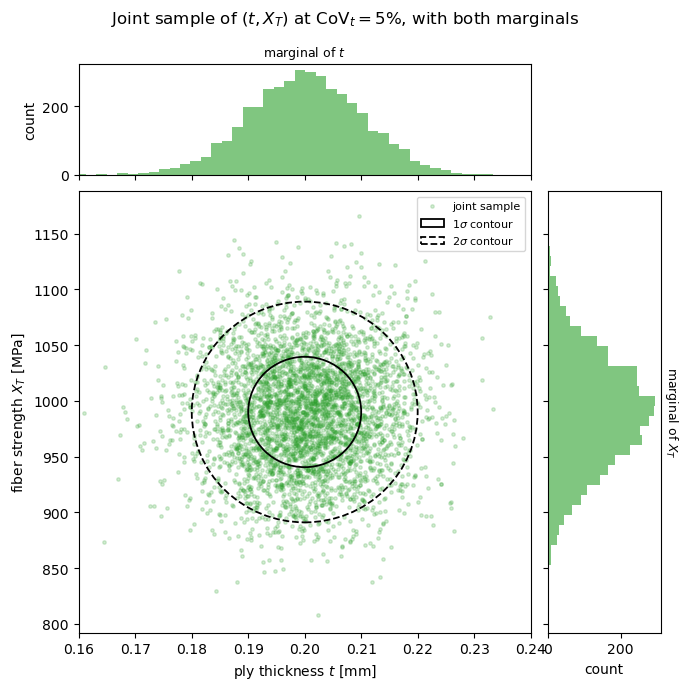

sample Pearson correlation between t and X_T : +0.0213   (independent draws -> expect 0 +- 1/sqrt(N) = +-0.0158)
marginal of t   : mean 0.2000 mm,  std 0.0100 mm,  CoV_t  0.0498  (asked for 0.0500)
marginal of X_T : mean 989.3 MPa, std 49.66 MPa, CoV_XT 0.0502  (asked for 0.0500)


In [ ]:
import sys

import numpy as np

import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse   # the 1-sigma / 2-sigma contours drawn on the joint panel below


# This notebook's helper modules live in ../scripts. None of them touch Abaqus, so they are
# safe to import straight into a live kernel (unlike build_fiber_tension.py -- see NB1).
sys.path.insert(0, "../scripts")

# The two input marginals (NB1's geometry, NB2's own X_T distribution).
MU_X, SIGMA_X = 990.0, 49.5     # MPa  -- X_T ~ N(990, 49.5): NB2's own mean and (illustrative) scatter
COV_XT = SIGMA_X / MU_X         # 0.05 -- the fiber-strength coefficient of variation
W  = 10.0                       # mm   -- gauge width (NB1 geometry), a fixed constant here
T0 = 0.20                       # mm   -- nominal ply thickness (NB1 geometry); A = W*T0 = 2 mm^2 in NB2

# Named seeds for the two INPUT generators, used throughout the notebook. Drawing X_T and t
# from two separate generators is what makes them independent by construction -- see the
# markdown above.
SEED_XT = 2   # X_T's own seed, shared with NB2 and NB3
SEED_T  = 4   # the shared standard-normal draw that becomes t (Part 3 explains "shared")

# ---------------------------------------------------------------------------------------
# One joint draw, purely to look at. It uses CoV_t = 5% -- the widest case in this notebook's
# later sweep -- so the cloud is actually visible.
# ---------------------------------------------------------------------------------------
N_LOOK = 4000
COV_T_LOOK = 0.05
SIGMA_T_LOOK = COV_T_LOOK * T0                                            # mm, the thickness std for this picture
x_look = np.random.default_rng(SEED_XT).normal(MU_X, SIGMA_X, N_LOOK)     # X_T draw
z_look = np.random.default_rng(SEED_T).standard_normal(N_LOOK)           # shared standard-normal draw
t_look = T0 * (1.0 + COV_T_LOOK * z_look)                                 # turn that draw into a thickness in mm

# ---------------------------------------------------------------------------------------
# The figure: a big joint panel with a marginal histogram glued to each of its two axes.
# A 2x2 grid does this -- the top-left cell holds t's marginal, the bottom-right cell holds
# X_T's, the bottom-left holds the joint scatter, and the top-right is left empty.
# ---------------------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(7, 7),
                         gridspec_kw=dict(width_ratios=[4, 1],    # joint panel 4x wider than X_T's marginal
                                          height_ratios=[1, 4]))  # joint panel 4x taller than t's marginal
ax_top, ax_main, ax_right = axes[0, 0], axes[1, 0], axes[1, 1]
axes[0, 1].axis("off")        # the unused corner

# The joint sample itself, plus its 1-sigma and 2-sigma contours. For two INDEPENDENT Normals
# the contours are axis-aligned ellipses centred on (t0, mu_X) with semi-axes k*sigma_t and
# k*sigma_X -- no tilt, because no correlation. Ellipse() wants full widths, hence the factor 2.
ax_main.scatter(t_look, x_look, s=6, alpha=0.20, color="C2", label="joint sample")
for k, ls in ((1, "-"), (2, "--")):
    ax_main.add_patch(Ellipse((T0, MU_X), 2 * k * SIGMA_T_LOOK, 2 * k * SIGMA_X,
                              fill=False, edgecolor="k", lw=1.3, ls=ls, zorder=3,
                              label=rf"${k}\sigma$ contour"))

# Axis limits pinned to +-4 sigma on each axis: this makes the contours above render as circles
# (rather than ellipses), and lets the two marginal panels share limits with the joint panel.
ax_main.set_xlim(T0 - 4 * SIGMA_T_LOOK, T0 + 4 * SIGMA_T_LOOK)
ax_main.set_ylim(MU_X - 4 * SIGMA_X, MU_X + 4 * SIGMA_X)
ax_main.set_xlabel("ply thickness $t$ [mm]")
ax_main.set_ylabel("fiber strength $X_T$ [MPa]")
ax_main.legend(fontsize=8, loc="upper right")

# t's marginal, on top, sharing the joint panel's x-range.
ax_top.hist(t_look, bins=40, color="C2", alpha=0.6)
ax_top.set_xlim(ax_main.get_xlim())
ax_top.set_ylabel("count")
ax_top.tick_params(labelbottom=False)        # the shared x-axis is already labelled below
ax_top.set_title("marginal of $t$", fontsize=9)

# X_T's marginal, on the right, sharing the joint panel's y-range and drawn sideways. Its own
# label goes on the RIGHT-hand spine, rotated -90 degrees so it reads downwards.
ax_right.hist(x_look, bins=40, orientation="horizontal", color="C2", alpha=0.6)
ax_right.set_ylim(ax_main.get_ylim())
ax_right.set_xlabel("count")
ax_right.tick_params(labelleft=False)        # the shared y-axis is already labelled on the left
ax_right.yaxis.set_label_position("right")
ax_right.set_ylabel("marginal of $X_T$", rotation=-90, labelpad=14, fontsize=9)

fig.suptitle(r"Joint sample of $(t, X_T)$ at $\mathrm{CoV}_t=5\%$, with both marginals")
fig.tight_layout()
fig.subplots_adjust(wspace=0.06, hspace=0.06)   # after tight_layout, which would otherwise reset the gaps
plt.show()

# ---------------------------------------------------------------------------------------
# The numbers behind the picture: the sample correlation (the direct check of independence)
# and each marginal's realised mean / std / CoV.
# ---------------------------------------------------------------------------------------
r_pearson = float(np.corrcoef(t_look, x_look)[0, 1])
print(f"sample Pearson correlation between t and X_T : {r_pearson:+.4f}   "
      f"(close to 0, as expected for independent draws)")
print(f"marginal of t   : mean {t_look.mean():.4f} mm,  std {t_look.std(ddof=1):.4f} mm,  "
      f"CoV_t  {t_look.std(ddof=1)/t_look.mean():.4f}  (asked for {COV_T_LOOK:.4f})")
print(f"marginal of X_T : mean {x_look.mean():.1f} MPa, std {x_look.std(ddof=1):.2f} MPa, "
      f"CoV_XT {x_look.std(ddof=1)/x_look.mean():.4f}  (asked for {COV_XT:.4f})")

The cloud fills the two contours symmetrically and shows no tilt: slicing it vertically at any
$t$ gives the same spread of $X_T$ as slicing it anywhere else. That is what independence looks
like as data, and it is why the contours came out as circles rather than as ellipses leaning
along a diagonal, which is what a correlated pair would have produced. The printed
sample correlation, about $0.02$, sits comfortably inside the sampling error that can be expected for a finite sample of $N=4000$ independent pairs shows around a true correlation of zero.

Each marginal comes out at the mean and coefficient of variation it was asked for, to within
ordinary sampling error. The joint distribution really is nothing more than the product of the
two marginals: with independence assumed, there is no third ingredient left to specify.

### No usable closed form for the output

With $X_T$ the only random input, $F_{peak}=A\cdot X_T$ was a **linear** map, and NB2 got the
entire output distribution for free: a linear transform of a Normal is Normal, so
$F_{peak}\sim\mathcal N(A\mu,\ A\sigma)$, percentiles and all.

That does not survive the addition of $t$ as a second random input in our case. $F_{peak}=w\,t\,X_T$ is now a **product** of two
random variables, and a product of two independent Normals is not itself Normal. Its exact
density is known only as an infinite series of modified Bessel functions of the second kind (see [Craig, 1936](https://doi.org/10.1214/aoms/1177732541) and [Cui et al., 2016](https://doi.org/10.1109/LSP.2016.2614539)). There is no elementary formula to write down, and no closed-form percentile to invert the way `scipy.stats.norm.ppf` inverts a Normal CDF. So there is no analytical output distribution to check a campaign against, and no analytical $Q_{5\%}$ to read off.

One fact about that exact density is still useful here: as the ratio $\mu/\sigma$ of each input parameter grows, [Aroian (1947)](https://doi.org/10.1214/aoms/1177730442) shows the product approaches a Normal shape. Both input parameters in this notebook will have $\mu/\sigma=1/\mathrm{CoV}=20$ at a certain point,
so the output stays close to Normal in shape throughout, a property Part 2 will lean on.

What *can* still be written down exactly, with no distributional assumption beyond
independence and finite variance, is the output's **mean and variance**, and, through
them, its coefficient of variation. That is the subject of the next section, and it is the
quantity the sample-size argument in Part 2 turns on.

### The one thing still exact: the output's coefficient of variation

Write $t$ and $X_T$ as independent random variables with means $\mu_t,\mu_X$ and variances
$\sigma_t^2,\sigma_X^2$. We use the following steps to compute the coefficient of variation of the product $F_{peak}=w\,t\,X_T$.

**Step 1 &ndash; the mean of the product.** For independent random variables the expectation
factorises:

$$\mathrm{E}[t\,X_T] = \mathrm{E}[t]\,\mathrm{E}[X_T] = \mu_t\,\mu_X.$$

So $\mathrm{E}[F_{peak}] = w\,\mu_t\,\mu_X$: the mean peak force is just the formula evaluated
at the two nominal values. This means that making $t$ random about a fixed mean (on top of $X_T$ random) does **not** move the mean of the output.

**Step 2 &ndash; the mean of the square.** Again by independence,

$$\mathrm{E}\!\left[(t\,X_T)^2\right] = \mathrm{E}[t^2]\,\mathrm{E}[X_T^2]
= (\mu_t^2 + \sigma_t^2)(\mu_X^2 + \sigma_X^2),$$

using $\mathrm{E}[Y^2] = \mathrm{E}[Y]^2 + \mathrm{Var}(Y)$ for each parameter.

**Step 3 &ndash; assemble the variance.** $\mathrm{Var}(t\,X_T) = \mathrm{E}[(t X_T)^2] -
\mathrm{E}[t X_T]^2$, so

$$\mathrm{Var}(t\,X_T)
= (\mu_t^2 + \sigma_t^2)(\mu_X^2 + \sigma_X^2) - \mu_t^2\,\mu_X^2
= \mu_t^2\,\sigma_X^2 + \mu_X^2\,\sigma_t^2 + \sigma_t^2\,\sigma_X^2.$$

The first two terms are what a first-order (linearised) propagation would give; the third,
$\sigma_t^2\sigma_X^2$, is the genuinely second-order piece that a product carries and a sum
does not.

**Step 4 &ndash; divide by the squared mean to get the CoV.** Dividing $\mathrm{Var}(t X_T)$
by $\mathrm{E}[t X_T]^2 = \mu_t^2\mu_X^2$, every term turns into a ratio of a variance to its
own squared mean, i.e. a squared coefficient of variation:

$$\boxed{\ \mathrm{CoV}_F^2 \;=\; \mathrm{CoV}_t^2 + \mathrm{CoV}_{X_T}^2
+ \mathrm{CoV}_t^2\,\mathrm{CoV}_{X_T}^2\ }$$

where $\mathrm{CoV}_F=\mathrm{CoV}(w\,t\,X_T)=\mathrm{CoV}(t\,X_T)$, since the constant $w$
cancels out of any coefficient of variation (see also [Goodman, 1960](https://doi.org/10.1080/01621459.1960.10483369)).

**How far this reaches.** Steps 1&ndash;4 used exactly two things: that $t$ and $X_T$ are
independent, and that both have finite variance. No distributional shape was assumed at any
point. The boxed identity therefore holds for *any* two independent inputs and the Normality
we assume in this notebook for our uncertain input parameters is doing no work whatsoever here. What *is* specific to this
model is the multiplicative form of the map: it is because $F_{peak}$ is a product that the
CoVs combine this cleanly, and a different map would combine them differently (a sum, for
instance, adds variances rather than squared CoVs).

The cell below evaluates it for three cases: $(\mathrm{CoV}_t, \mathrm{CoV}_{X_T}) = (0.05, 0.05)$, $(0.1, 0.05)$, and $(0.05, 0.1)$; and checks it against a brute-force draw ($N=500,000$).

In [2]:
# The three cases swept throughout the rest of this notebook. CoV_t = 0 is NB3's one-input
# problem; the other two make t random. These CoV_t values are ILLUSTRATIVE sweep points
# chosen to demonstrate a mechanism, NOT a sourced estimate of real ply-thickness scatter. For
# orientation only: Thapa et al. (2021) apply a single blanket CoV of 0.10 to every random
# material property in their progressive-failure UQ study, and name ply thickness explicitly
# as a meso-scale uncertainty source; 2% and 5% sit below that on purpose, so that the
# "small scatter" case is genuinely small.
COV_T_CASES = [0.0, 0.02, 0.05]
CASE_COLOR  = {0.0: "C0", 0.02: "C1", 0.05: "C2"}   # one colour per case, used in every figure


def combined_cov(cov_t, cov_xt=COV_XT):
    """Exact CoV of the product t*X_T for INDEPENDENT t and X_T -- the boxed identity above.
    Needs only independence and finite variance; no distributional assumption at all."""
    return np.sqrt(cov_t**2 + cov_xt**2 + cov_t**2 * cov_xt**2)


# Rather than trust the algebra, evaluate the same quantity a second way: draw half a million
# (t, X_T) pairs, form the product, and measure its CoV directly. The two should agree to
# within ordinary Monte Carlo scatter at that sample size.
N_CHECK = 500_000
x_chk = np.random.default_rng(SEED_XT).normal(MU_X, SIGMA_X, N_CHECK)   # X_T draws
z_chk = np.random.default_rng(SEED_T).standard_normal(N_CHECK)         # shared standard-normal draw, reused per case

print(f"{'CoV_t':>8}{'CoV_XT':>9}{'cross term':>13}{'CoV_F exact':>14}{'CoV_F empirical':>18}{'rel. err':>11}")
print("-" * 73)
for cov_t in COV_T_CASES:
    exact = combined_cov(cov_t)                       # from the boxed identity
    cross = cov_t**2 * COV_XT**2                      # the second-order term, printed on its own
    t_chk = T0 * (1.0 + cov_t * z_chk)                # this case's thickness draws
    f_chk = W * t_chk * x_chk                         # the peak forces they imply
    emp = f_chk.std(ddof=1) / f_chk.mean()            # measured CoV of the product
    print(f"{cov_t:8.2f}{COV_XT:9.3f}{cross:13.2e}{exact:14.5f}{emp:18.5f}{(emp - exact) / exact:+11.2%}")

   CoV_t   CoV_XT   cross term   CoV_F exact   CoV_F empirical   rel. err
-------------------------------------------------------------------------
    0.00    0.050     0.00e+00       0.05000           0.04998     -0.03%
    0.02    0.050     1.00e-06       0.05386           0.05388     +0.04%
    0.05    0.050     6.25e-06       0.07075           0.07079     +0.05%


The identity lands on the brute-force draw to within a few hundredths of a percent, which is
ordinary Monte Carlo scatter at half a million samples. The cross term
$\mathrm{CoV}_t^2\,\mathrm{CoV}_{X_T}^2$ is at most a few parts in $10^6$: utterly negligible
at these CoVs, so in practice the two coefficients of variation combine as a plain quadrature
sum, $\mathrm{CoV}_F\approx\sqrt{\mathrm{CoV}_t^2 + \mathrm{CoV}_{X_T}^2}$. Note that essentially this is a
statement about the *size* of the CoVs: at CoVs of order one the cross term would matter.

The numbers that matter for the rest of the notebook: adding a second uncertain input takes
the output CoV from $5.00\%$ (thickness fixed) to $5.39\%$ at $\mathrm{CoV}_t=2\%$, and to
$7.08\%$ at $\mathrm{CoV}_t=5\%$. For our model, a second input with small scatter barely widens the output;
a second input with larger scatter widens it substantially, here by more than $40\%$ in
relative terms.

## Part 2 &ndash; Why the required $N$ tracks scatter, not the number of inputs

Part 1 gave the output's CoV exactly. This Part connects that CoV to the Monte Carlo cost of
resolving a percentile, and shows the number of inputs never enters.

### The asymptotic standard error of a sample quantile

Fix a probability level $p$ (here $p=0.05$) and let $Q_p$ be the true value the sample's
$p$-th percentile is estimating. We can build the standard error of the estimate $\widehat Q_p$ in three steps.

**1. The vertical wobble.** For each draw $F_i$, define the indicator $I_i = 1$ if $F_i\le
Q_p$ and $0$ otherwise. By the very definition of $Q_p$, $\mathrm P(F\le Q_p)=p$, so each
$I_i$ is a coin flip landing "below $Q_p$" with probability exactly $p$. A $0/1$ variable
satisfies $I^2=I$, so $\mathrm E[I]=p$ and $\mathrm{Var}(I)=\mathrm E[I^2]-\mathrm
E[I]^2=p-p^2=p(1-p)$. The **sample fraction below $Q_p$** is the average of $N$ independent copies of $I$, so it has mean $p$ and
standard deviation $\sqrt{p(1-p)/N}$: an ordinary standard error of a proportion, nothing more.
This is an error measured **vertically**, on the probability axis.

**2. Turning vertical into horizontal.** What is actually wanted is the error in the estimated
**quantile** $\widehat Q_p$, measured horizontally, on the force axis. The CDF's value at a
force level $q$ *is*, by definition, the probability of landing below $q$, and the density
$f$ is its derivative: raising $q$ by a small $\Delta q$ near $Q_p$ raises that probability by
about $f(Q_p)\,\Delta q$. Read backwards, a probability-axis discrepancy $\varepsilon$
corresponds to a force-axis discrepancy of about $\varepsilon / f(Q_p)$: the *steeper* the CDF
climbs at $Q_p$ (the higher the density there), the *less* a given vertical wobble moves the
estimated quantile.

**3. Assemble.** $\widehat Q_p$ is, informally, the force level at which the empirical CDF
reaches $p$. Dividing its vertical wobble (step 1) by the local slope (step 2) gives its
horizontal wobble, i.e. the standard error of the quantile estimator:

$$SE(\widehat Q_p) \;=\; \frac{1}{f(Q_p)}\sqrt{\frac{p(1-p)}{N}}.$$

This heuristic is a classical order-statistics result (see [David & Nagaraja, 2003](https://doi.org/10.1002/0471722162), §10.3), under only the conditions that the output be continuous with a strictly positive density at the quantile of interest ($0<p<1$, $0<f(Q_p)<\infty$). Nothing in those conditions refers to a distributional family, which is why the result is usable *here*, on a product of Normals whose own shape has no elementary closed form: the formula still applies, the only thing lost is the ability to write $f(Q_p)$ itself down exactly. It applies equally to to any other output this series will eventually produce.

### The consequence: $N \propto \mathrm{CoV}_F^{\,2}$, with no input count anywhere

$SE(\widehat Q_p)$ contains $f(Q_p)$, the output's density at its own 5th percentile, a number that, here, cannot be written down exactly. But sizing a campaign only needs to know how $f(Q_p)$ **responds** to $\mathrm{CoV}_t$ growing, not its exact value, and that response follows from one elementary fact.

**A density integrates to 1.** Stretch a distribution horizontally by a factor $k$ without
changing its shape (every value $x$ maps to $kx$), and the area under its curve must still be
1 afterwards; since the curve now spans $k$ times the range, every one of its height values
must shrink by that same factor $k$ to keep the area unchanged. So for two distributions of
the *same shape*, the one with $k$ times the spread has $1/k$ times the peak density
everywhere, including at the corresponding quantile: $f(Q_p)\propto 1/\sigma_F$.

Does "same shape, different scale" describe what $\mathrm{CoV}_t$ does to our output $F_{peak}$? Two
things say yes. First, Part 1, Step 1 showed $\mathrm{CoV}_t$ enters $F_{peak}$ only through
its spread, not its mean, so growing $\mathrm{CoV}_t$ is exactly a rescaling of $\sigma_F$ with
$\mu_F$ held fixed. Second, [Aroian (1947)](https://doi.org/10.1214/aoms/1177730442)'s result shows that the output stays close to Normal as the ratio $\mu_F/\sigma_F$ increases. For a Normal distribution the relation between the density at a quantile and the standard deviation is exact: $f(Q_p)=\varphi(z_p)/\sigma_F$, with $z_p$ being the $p$-th quantile of the standard Normal distribution.

Substituting $f(Q_p)\propto 1/\sigma_F$ into the standard error and dividing by $Q_p$ itself
gives a *relative* error:

$$\mathrm{relSE}(\widehat Q_p)
= \frac{SE(\widehat Q_p)}{Q_p}
\;\propto\; \frac{\sigma_F}{Q_p}\,\frac{1}{\sqrt N}
\;\propto\; \frac{\mathrm{CoV}_F}{\sqrt N},$$

using $Q_p\propto\mu_F$ to leading order (the tail sits a fixed number of standard deviations
from a mean that, per Part 1, does not move). Fixing that relative error at a target tolerance
and solving for $N$:

$$\boxed{\ N \;\propto\; \mathrm{CoV}_F^{\,2}\ }$$

**The number of inputs appears nowhere in this expression.** Inputs enter only through
$\mathrm{CoV}_F$, and only via Part 1's quadrature: a second input with small CoV nudges
$\mathrm{CoV}_F$ up a little and the required $N$ barely moves; a second input with large CoV
pushes $\mathrm{CoV}_F$ up a lot and $N$ grows with its square, at the same input count
either way. This is the same scaling NB2 met for the mean, $\mathrm{relSE}(\widehat\mu)=\mathrm{CoV}/\sqrt N$: a larger relative spread on the quantity
being estimated costs more samples, whether that quantity is a mean or a percentile.

Since only the *ratio* of two $N$'s is needed to test this, and the unknown proportionality
constant cancels in a ratio, the cell below turns the three output CoVs into three predicted
sample-size ratios.

In [3]:
# N ~ CoV_F^2 fixes only ratios, not absolute sample sizes: the proportionality constant
# involves f(Q_p), which is exactly the thing that cannot be written down here. Taking the
# CoV_t = 0 case as the reference makes that constant cancel.
#
# This is a PREDICTION to be tested against the bootstrap monitor in Part 3, not a sizing
# recipe. Every actual N below is decided by NB3's convergence criterion; nothing on this line
# is used to stop a campaign.
cov_f_ref = combined_cov(0.0)                    # the one-input baseline's output CoV

print(f"{'CoV_t':>8}{'CoV_F':>10}{'predicted N ratio':>20}")
print(f"{'':>8}{'':>10}{'(CoV_F / CoV_F|CoV_t=0)^2':>26}")
print("-" * 46)
for cov_t in COV_T_CASES:
    cov_f = combined_cov(cov_t)
    print(f"{cov_t:8.2f}{cov_f:10.5f}{(cov_f / cov_f_ref)**2:20.3f}")

   CoV_t     CoV_F   predicted N ratio
                   (CoV_F / CoV_F|CoV_t=0)^2
----------------------------------------------
    0.00   0.05000               1.000
    0.02   0.05386               1.160
    0.05   0.07075               2.003


The prediction: relative to the one-input baseline, the $\mathrm{CoV}_t=2\%$ case should need
about $1.16\times$ the samples, and the $\mathrm{CoV}_t=5\%$ case about $2.0\times$: a
doubling of cost from adding scatter to a second input, with no change at all in the number of
inputs. Part 3 runs the actual bootstrap-monitored campaigns and checks these two ratios.

## Part 3 &ndash; Three campaigns: $\mathrm{CoV}_t = 0$, $2\%$ and $5\%$

All three cases are run the same way, through the same machinery, changing one number:

- The **fiber strength** comes from the identical $\mathcal N(990,\,49.5)$, seed-2 pool used
  throughout NB2 and NB3, so the $\mathrm{CoV}_t=0$ case is literally NB3's own problem.
- The **thickness** is $t = t_0\,(1 + \mathrm{CoV}_t\cdot z)$, built from a single shared
  standard-normal draw $z$ (seed 4) reused by every case. This is the "common random numbers"
  trick: because the three cases differ *only* in the multiplier on $z$, any difference
  between their results is the effect of scatter and not of having drawn three unrelated
  samples. At $\mathrm{CoV}_t=0$ the multiplier is zero and $t\equiv t_0$, so the one-input
  case falls out of the same expression rather than being special-cased. The $2\%$ and $5\%$
  values are illustrative sweep points picked to make the change in $F_{peak}$'s distribution
  visible.
- The **stopping rule** is the same as in NB3: bootstrap a 95% confidence interval on the order-statistic $\widehat Q_{5\%}$ after every batch of 10 new
  samples, with $B=1000$ resamples, and stop the first time its relative half-width reaches
  $1\%$. No check runs below $n_{\min}$, the sample size below which such an interval cannot
  exist at all. Each case gets its own seeded bootstrap generator (101, 102, 103) so the three
  sets of checks are independent of one another. The functions to compute the bootstrap confidence interval are imported from the module `bootstrap.py`.

**Seed recap.** By this point the notebook uses six seeds; grouping them by role:

| seed(s) | draws | shared or per-case? |
|---|---|---|
| 2 | the $X_T$ pool, $\mathcal N(990,\,49.5)$ | **shared** &ndash; identical across all three cases |
| 4 | the standard-normal draw $z$ that becomes $t$ | **shared** &ndash; identical across all three cases |
| 101, 102, 103 | bootstrap resampling inside each case's convergence checker | **per case** &ndash; one seed each (101 is NB3 Campaign A's own) |

The two **input** seeds (2 and 4) are deliberately shared across the three cases: common
random numbers, so any difference in a campaign's outcome is attributable to $\mathrm{CoV}_t$
and not to having drawn three unrelated samples. The three **bootstrap** seeds are deliberately
distinct: each case's convergence checks must be independent of the other two cases', or a
comparison between their convergence trajectories would not be a fair one. Part 4 introduces a
second, analogous pair of per-case bootstrap seeds (201, 202, 203) for its own, separate
confidence intervals.

One caveat carried over from NB2's treatment of $X_T$: a Normal marginal distribution for $t$ assigns a
tiny probability to $t \le 0$, which is unphysical. At $\mathrm{CoV}_t=5\%$ that is $20$
standard deviations out, so it never occurs in any pool used here.

The cell below draws the pools and defines the batching driver.

In [4]:
from bootstrap import (                       # NB3 Parts 1-2's own machinery, now a shared module
    ConvergenceChecker,                       #   the stateful 1%-relative-half-width stopping rule
    bootstrap_ci,                             #   the percentile-method bootstrap CI, used again in Part 4
    min_samples_for_quantile_ci,              #   the smallest N at which such an interval can exist
)

# ---------------------------------------------------------------------------------------
# 1. The two input pools, drawn once and reused by all three cases.
#    N_MAX only has to be large enough that the slowest case converges before running out;
#    NB3 used 2000, and the CoV_t = 5% case below needs more than that.
# ---------------------------------------------------------------------------------------
N_MAX = 4000
x_pool        = np.random.default_rng(SEED_XT).normal(MU_X, SIGMA_X, N_MAX)   # X_T pool
z_shared_pool = np.random.default_rng(SEED_T).standard_normal(N_MAX)         # shared standard-normal draw

# ---------------------------------------------------------------------------------------
# 2. The stopping rule's two fixed ingredients.
# ---------------------------------------------------------------------------------------
# n_min: below this many samples, a 95% distribution-free interval on a 5th percentile cannot
# exist at all, however tight the bootstrap makes it look (NB3 Part 2 derives the bound
# p**N + (1-p)**N <= alpha; the function carries that derivation in its docstring).
N_MIN = min_samples_for_quantile_ci(p=0.05, alpha=0.05, batch_size=10)
BATCH = 10          # samples added between successive convergence checks (NB3's own grid)
N_BOOT = 1000       # bootstrap resamples per check (NB3 Part 1 sizes this empirically)
TARGET = 0.01       # stop when the relative half-width reaches 1% (NB3's own target)
CHECKER_SEED = {0.0: 101, 0.02: 102, 0.05: 103}   # 101 is NB3 Campaign A's own seed

print(f"n_min (NB3 Part 2's existence bound, rounded onto a {BATCH}-sample check grid): {N_MIN}")


def run_until_converged_algebraic(f_pool, checker, n_min=N_MIN, batch_size=BATCH):
    """Grow a campaign in batches until `checker` says the estimate is precise enough.

    NB3's `run_until_converged` grew a campaign by handing a longer prefix of the input pool
    to `run_campaign`, which launched that many more Abaqus jobs; here F_peak is already known
    in closed form for the whole pool, so "running the next batch" is just taking a longer
    slice of `f_pool`. Everything else -- starting at n_min, checking once per batch, stopping
    on the first pass -- is unchanged.

    Returns the sample size at which the criterion first passed.
    """
    for n in range(n_min, len(f_pool) + 1, batch_size):
        # checker.check bootstraps a fresh CI on the first n samples, records it in its own
        # history (which the convergence plot below reads back), prints one line, and returns
        # True the first time the relative half-width reaches the target.
        if checker.check(f_pool[:n]):
            return n
    raise RuntimeError(f"f_pool exhausted at n={len(f_pool)} without converging.")

n_min (NB3 Part 2's existence bound, rounded onto a 10-sample check grid): 60


`run_until_converged_algebraic` is the only genuinely new piece of code in this notebook, and
it is new only in the sense that it replaces a subprocess call with an array slice: because
$F_{peak}$ is known in closed form for every draw in the pool, "run the next ten samples"
costs nothing and the loop reduces to widening a slice. The convergence criterion it drives is
NB3's own class, imported unchanged.

The cell below runs all three cases through it and writes each campaign, together with the full history of its convergence checks, to `runs/nb04/`. Expect a long printout: one line per convergence check, per case.

In [5]:
import csv
import json
from pathlib import Path

RUNS_DIR = Path("../runs/nb04")
RUNS_DIR.mkdir(parents=True, exist_ok=True)
CASE_TAG = {0.0: "cov00", 0.02: "cov02", 0.05: "cov05"}   # file-name stem per case

results = {}
for cov_t in COV_T_CASES:
    # ---- build this case's peak forces, straight from the closed form --------------------
    t_pool = T0 * (1.0 + cov_t * z_shared_pool)  # at cov_t = 0 this is just t0 everywhere
    assert (t_pool > 0).all(), f"CoV_t={cov_t}: drew a non-physical t <= 0 (see the note above)."
    f_pool = W * t_pool * x_pool                # F_peak = w * t * X_T, one value per pool entry

    # ---- converge it against NB3's criterion ---------------------------------------------
    checker = ConvergenceChecker(f"CoV_t={cov_t:.0%}", p=0.05, target_rel_half_width=TARGET,
                                 n_boot=N_BOOT, rng=np.random.default_rng(CHECKER_SEED[cov_t]))
    N = run_until_converged_algebraic(f_pool, checker)

    # ---- keep only the converged prefix; that is the campaign this notebook reports on ----
    results[cov_t] = dict(N=N, checker=checker,
                          f=f_pool[:N], t=t_pool[:N], x=x_pool[:N])
    print(f"CoV_t={cov_t:.0%}  ->  converged at N = {N}\n")

# ---------------------------------------------------------------------------------------
# Persist each campaign two ways: the samples themselves as a CSV (one row per draw), and the
# convergence history as JSON (one entry per check). The bootstrap replicates are dropped from
# the history -- they are a 1000-element array per check, and nothing downstream reads them.
# ---------------------------------------------------------------------------------------
for cov_t, tag in CASE_TAG.items():
    r = results[cov_t]
    with open(RUNS_DIR / f"campaign_{tag}.csv", "w", newline="") as fh:
        writer = csv.writer(fh)
        writer.writerow(["sample_index", "t_mm", "x_t_mpa", "f_peak_n"])
        for i in range(r["N"]):
            writer.writerow([i, f"{r['t'][i]:.10f}", f"{r['x'][i]:.10f}", f"{r['f'][i]:.10f}"])
    history = [{k: v for k, v in h.items() if k != "replicates"} for h in r["checker"].history]
    with open(RUNS_DIR / f"convergence_{tag}.json", "w") as fh:
        json.dump({"cov_t": cov_t, "checker_seed": CHECKER_SEED[cov_t],
                   "n_converged": r["N"], "history": history}, fh, indent=2)

print("wrote campaign_{cov00,cov02,cov05}.csv and convergence_{cov00,cov02,cov05}.json "
      f"to {RUNS_DIR.as_posix()}/")

[CoV_t=0%] n=  60  Q5%_hat= 1817.34 N  95% CI=[ 1791.80,  1879.35]  rel_half_width=2.409%  (not yet)
[CoV_t=0%] n=  70  Q5%_hat= 1812.84 N  95% CI=[ 1739.05,  1870.41]  rel_half_width=3.623%  (not yet)
[CoV_t=0%] n=  80  Q5%_hat= 1817.34 N  95% CI=[ 1739.05,  1867.54]  rel_half_width=3.535%  (not yet)
[CoV_t=0%] n=  90  Q5%_hat= 1822.63 N  95% CI=[ 1770.43,  1870.41]  rel_half_width=2.743%  (not yet)
[CoV_t=0%] n= 100  Q5%_hat= 1828.00 N  95% CI=[ 1791.84,  1874.37]  rel_half_width=2.257%  (not yet)
[CoV_t=0%] n= 110  Q5%_hat= 1826.35 N  95% CI=[ 1794.62,  1871.87]  rel_half_width=2.115%  (not yet)
[CoV_t=0%] n= 120  Q5%_hat= 1824.22 N  95% CI=[ 1785.13,  1873.18]  rel_half_width=2.413%  (not yet)
[CoV_t=0%] n= 130  Q5%_hat= 1826.35 N  95% CI=[ 1794.62,  1871.00]  rel_half_width=2.091%  (not yet)
[CoV_t=0%] n= 140  Q5%_hat= 1828.34 N  95% CI=[ 1794.62,  1872.93]  rel_half_width=2.141%  (not yet)
[CoV_t=0%] n= 150  Q5%_hat= 1826.80 N  95% CI=[ 1801.00,  1873.17]  rel_half_width=1.976%  

The three cases converge at $N = 370$, $380$ and $700$. Before reading anything into that, one
consistency check: the $\mathrm{CoV}_t=0$ case stopped at $N=370$ with
$\widehat Q_{5\%}=1805.83$ N and a relative half-width of $0.993\%$. These are exactly the numbers
NB3's Campaign A reports for its `nlgeom=OFF` campaign, to the digit. That is not a
coincidence and not really a test of anything new: it is the same $X_T$ draw, the same
stopping rule, and the same bootstrap seed, differing only in that NB3 obtained its peak forces
from 370 Abaqus jobs and this notebook read them off the closed form. It does confirm that
nothing has drifted in the machinery between the two notebooks.

The interesting comparison is the other two. The cell below plots all three convergence
trajectories, showing the bootstrap relative half-width against the number of samples,
so *how* each campaign approached the 1% target.

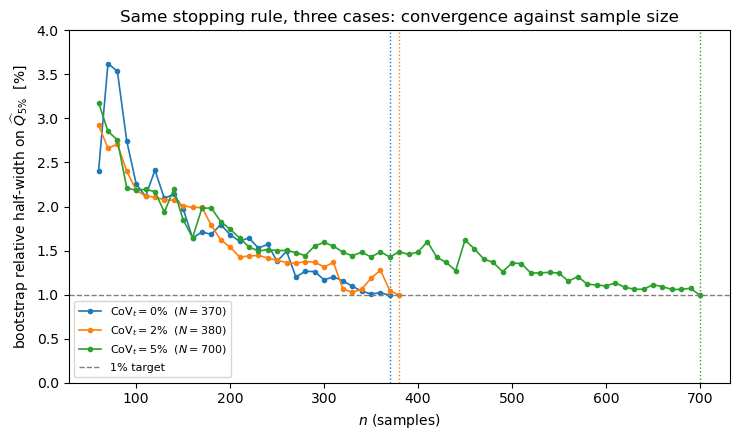

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))

for cov_t in COV_T_CASES:
    # checker.history holds one dict per convergence check, in the order they were made, so a
    # pair of list comprehensions recovers the whole trajectory.
    history = results[cov_t]["checker"].history
    ns     = np.array([h["n"] for h in history])
    rel_hw = np.array([100 * h["rel_half_width"] for h in history])

    ax.plot(ns, rel_hw, "o-", ms=3, lw=1.2, color=CASE_COLOR[cov_t],
            label=rf"$\mathrm{{CoV}}_t={cov_t*100:.0f}\%$  ($N={results[cov_t]['N']}$)")
    # a dotted vertical at the sample size where this case's criterion first passed
    ax.axvline(results[cov_t]["N"], color=CASE_COLOR[cov_t], ls=":", lw=1)

# the one line every trajectory has to reach before its campaign stops
ax.axhline(1.0, color="gray", ls="--", lw=1, label="1% target")

ax.set_xlabel("$n$ (samples)")
ax.set_ylabel(r"bootstrap relative half-width on $\widehat{Q}_{5\%}$  [%]")
ax.set_title("Same stopping rule, three cases: convergence against sample size")
ax.set_ylim(0, 4)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

Read the three curves against each other. All start high and noisy, as at $n=60$ a
bootstrap interval on a 5th percentile is built on a handful of tail points. As $n$ increases, all
descend towards the 1% line, but they do not descend together. The $\mathrm{CoV}_t=2\%$ curve
(orange) tracks the one-input baseline (blue) closely the whole way down and crosses barely
later, at $N=380$ against $370$. The $\mathrm{CoV}_t=5\%$ curve (green) sits visibly above
both at about $1.5\%$ where the other two have already finished, only reaching the target at $N=700$.

None of the three descends monotonically; each wobbles across the last few batches before
crossing, which is the behaviour NB3 documented for its own campaigns and a reminder that the
precise stopping point is decided partly by which side of the line a noisy statistic happens
to land on. What the plot shows unambiguously is the *separation between* the curves. Since the $2\%$ and $5\%$ campaigns have the same number of uncertain inputs, that
separation can only be attributed to the difference in scatter they put into the output.

The cell below turns each converged campaign into a picture of the output distribution it actually produced, with both the histogram of the samples and the smooth kernel density estimate employing optimal bandwidth.

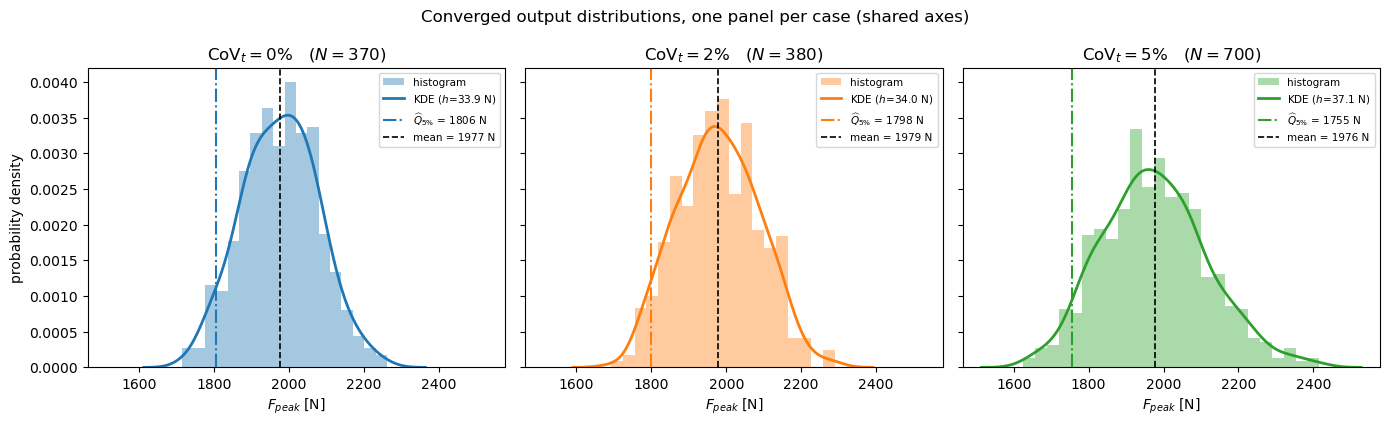

  CoV_t   mean [N]   std [N]  CoV_F emp.  CoV_F exact  Q5%_hat [N]
------------------------------------------------------------------
     0%    1976.50    100.94     0.05107      0.05000      1805.83
     2%    1978.78    107.79     0.05448      0.05386      1798.30
     5%    1976.31    141.08     0.07138      0.07075      1755.32


In [7]:
from kde import kde_loo_bandwidth, kde_pdf   # NB2 Part 5's own KDE functions, unchanged

# Sharing both axes across the three panels is the point of this figure: the shift in width
# from panel to panel is then a genuine visual comparison rather than three separate rescalings.
fig, axes = plt.subplots(1, 3, figsize=(14, 4.3), sharex=True, sharey=True)

kde_h = {}     # the cross-validated bandwidth per case, reused by the overlay figure in Part 4
for ax, cov_t in zip(axes, COV_T_CASES):
    f = results[cov_t]["f"]                         # this case's converged sample of peak forces
    color = CASE_COLOR[cov_t]

    # Bandwidth by leave-one-out cross-validation, NB2 Part 5's own method, imported unchanged:
    # the data chooses its own smoothing instead of it being read off a rule of thumb.
    h = kde_loo_bandwidth(f)[0]
    kde_h[cov_t] = h
    x_grid = np.linspace(f.min() - 3 * h, f.max() + 3 * h, 400)   # a few bandwidths of margin either side

    # the raw sample, binned...
    n_bins = min(25, max(5, len(f) // 20))          # roughly one bin per 20 samples, floored and capped
    ax.hist(f, bins=n_bins, density=True, color=color, alpha=0.4, label="histogram")
    # ...and the same sample smoothed
    ax.plot(x_grid, kde_pdf(x_grid, f, h), color=color, lw=2, label=f"KDE ($h$={h:.1f} N)")

    # the two summary positions this notebook keeps returning to
    q5 = float(np.percentile(f, 5))                 # the order-statistic 5th percentile (NB3 Part 1)
    ax.axvline(q5, color=color, ls="-.", lw=1.5, label=rf"$\widehat{{Q}}_{{5\%}}$ = {q5:.0f} N")
    ax.axvline(f.mean(), color="k", ls="--", lw=1.2, label=f"mean = {f.mean():.0f} N")

    ax.set_xlabel("$F_{peak}$ [N]")
    ax.set_title(rf"$\mathrm{{CoV}}_t={cov_t*100:.0f}\%$   ($N={results[cov_t]['N']}$)")
    ax.legend(fontsize=7.5)

axes[0].set_ylabel("probability density")
fig.suptitle("Converged output distributions, one panel per case (shared axes)")
fig.tight_layout()
plt.show()

# The numbers behind the three panels, checked against Part 1's exact identity.
print(f"{'CoV_t':>7}{'mean [N]':>11}{'std [N]':>10}{'CoV_F emp.':>12}{'CoV_F exact':>13}{'Q5%_hat [N]':>13}")
print("-" * 66)
for cov_t in COV_T_CASES:
    f = results[cov_t]["f"]
    print(f"{cov_t:7.0%}{f.mean():11.2f}{f.std(ddof=1):10.2f}"
          f"{f.std(ddof=1) / f.mean():12.5f}{combined_cov(cov_t):13.5f}"
          f"{np.percentile(f, 5):13.2f}")

On shared axes the three panels tell a simple story: the black dashed mean sits in essentially
the same place in all three, while the distribution around it gets wider from left to right
and the dash-dot 5th percentile slides left. Each panel's histogram and KDE agree on the
shape, and the printed empirical $\mathrm{CoV}_F$ matches Part 1's exact identity in every
case to within about two percent of itself, the discrepancy being ordinary sampling
scatter on a standard deviation estimated from a few hundred samples.

Also worth noting for Part 2's sake: the three shapes look like the same bell stretched, not
like three different shapes. That was the one assumption behind $N\propto\mathrm{CoV}_F^2$: that $f(Q_p)$ scales like $1/\sigma_F$ because the shape is preserved, and it is
here verified in the plots.

## Part 4 &ndash; The three output distributions together

The cell below overlays the three kernel density estimates on a single axis, marks
each one's $\widehat Q_{5\%}$, and prints the full set of numbers this notebook has been
building towards: for every case, the exact and measured output CoV, the converged sample
size and how it compares to Part 2's prediction, and the mean, standard deviation and
5th percentile with its bootstrap confidence interval.

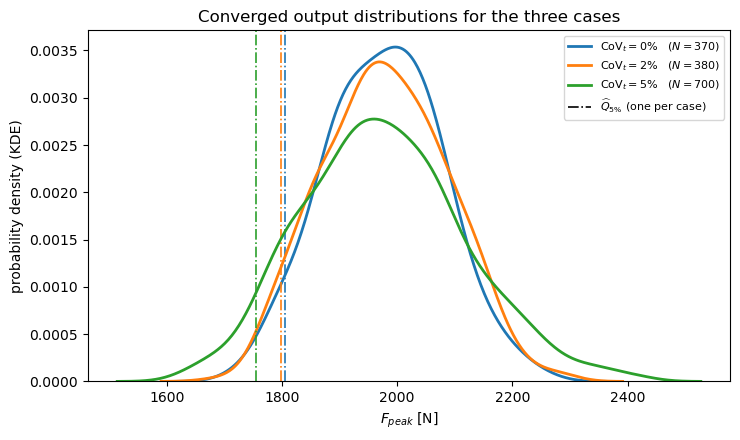

  CoV_t  CoV_F exact  CoV_F emp.     N  N ratio  pred. ratio   mean [N]   std [N]  Q5%_hat [N]        95% CI on Q5% [N]
-----------------------------------------------------------------------------------------------------------------------------------
     0%      0.05000     0.05107   370    1.000        1.000    1976.50    100.94      1805.83    [ 1789.08,  1824.93]
     2%      0.05386     0.05448   380    1.027        1.160    1978.78    107.79      1798.30    [ 1785.52,  1821.25]
     5%      0.07075     0.07138   700    1.892        2.003    1976.31    141.08      1755.32    [ 1744.30,  1779.11]

CoV_t=2%:  mean shift +0.115%   Q5% shift -0.42%   N grew +2.7%
CoV_t=5%:  mean shift -0.010%   Q5% shift -2.80%   N grew +89.2%

wrote summary_cov.json to ../runs/nb04/


In [8]:
from matplotlib.lines import Line2D   # builds a legend entry below with no data behind it

fig, ax = plt.subplots(figsize=(7.5, 4.5))

for cov_t in COV_T_CASES:
    f = results[cov_t]["f"]
    h = kde_h[cov_t]                                 # the bandwidth already cross-validated above
    x_grid = np.linspace(f.min() - 3 * h, f.max() + 3 * h, 500)
    ax.plot(x_grid, kde_pdf(x_grid, f, h), color=CASE_COLOR[cov_t], lw=2,
            label=rf"$\mathrm{{CoV}}_t={cov_t*100:.0f}\%$   ($N={results[cov_t]['N']}$)")
    # each case's 5th percentile, in that case's colour: colour says which case, linestyle says
    # what the line means
    ax.axvline(float(np.percentile(f, 5)), color=CASE_COLOR[cov_t], ls="-.", lw=1.2)

ax.set_xlabel("$F_{peak}$ [N]")
ax.set_ylabel("probability density (KDE)")
ax.set_title("Converged output distributions for the three cases")
ax.set_ylim(bottom=0)                                # densities start at zero; no reason to crop the axis

# The dash-dot verticals share a meaning but not a colour, so state the meaning once with a
# black proxy line -- a Line2D with no data behind it, added purely as a legend handle.
handles, labels = ax.get_legend_handles_labels()
handles.append(Line2D([0], [0], color="k", ls="-.", lw=1.2))
labels.append(r"$\widehat{Q}_{5\%}$ (one per case)")
ax.legend(handles, labels, fontsize=8)

fig.tight_layout()
plt.show()

# ---------------------------------------------------------------------------------------
# The summary table. One row per case, assembled into a dict so it can be both printed and
# written to disk without computing anything twice.
# ---------------------------------------------------------------------------------------
cov_f_ref = combined_cov(0.0)          # the one-input baseline, for the two ratio columns
N_ref = results[0.0]["N"]

rows = []
for cov_t in COV_T_CASES:
    r = results[cov_t]
    f = r["f"]
    last_check = r["checker"].history[-1]            # the check that triggered convergence
    rows.append(dict(
        cov_t=cov_t,
        cov_f_exact=combined_cov(cov_t),             # Part 1's boxed identity
        cov_f_emp=float(f.std(ddof=1) / f.mean()),   # measured on the converged sample
        N=r["N"],
        N_ratio=r["N"] / N_ref,                      # measured cost, relative to one input
        pred_ratio=(combined_cov(cov_t) / cov_f_ref) ** 2,   # Part 2's prediction for the same
        mean=float(f.mean()), std=float(f.std(ddof=1)),
        q5=float(np.percentile(f, 5)),
        ci_low=last_check["ci_low"], ci_high=last_check["ci_high"],
        kde_h=kde_h[cov_t],
    ))

print(f"{'CoV_t':>7}{'CoV_F exact':>13}{'CoV_F emp.':>12}{'N':>6}{'N ratio':>9}{'pred. ratio':>13}"
      f"{'mean [N]':>11}{'std [N]':>10}{'Q5%_hat [N]':>13}{'95% CI on Q5% [N]':>25}")
print("-" * 131)
for row in rows:
    print(f"{row['cov_t']:7.0%}{row['cov_f_exact']:13.5f}{row['cov_f_emp']:12.5f}{row['N']:6d}"
          f"{row['N_ratio']:9.3f}{row['pred_ratio']:13.3f}{row['mean']:11.2f}{row['std']:10.2f}"
          f"{row['q5']:13.2f}    [{row['ci_low']:8.2f}, {row['ci_high']:8.2f}]")

# The shifts relative to the one-input baseline, which is what the discussion below is about.
print()
for row in rows[1:]:
    print(f"CoV_t={row['cov_t']:.0%}:  mean shift {100*(row['mean']-rows[0]['mean'])/rows[0]['mean']:+.3f}%   "
          f"Q5% shift {100*(row['q5']-rows[0]['q5'])/rows[0]['q5']:+.2f}%   "
          f"N grew {100*(row['N_ratio']-1):+.1f}%")

with open(RUNS_DIR / "summary_cov.json", "w") as fh:
    json.dump(rows, fh, indent=2)
print(f"\nwrote summary_cov.json to {RUNS_DIR.as_posix()}/")

The KDE overlay shows the three distributions widening and their percentiles sliding left, but
a picture does not say whether a given shift is bigger than the campaigns' own sampling noise.
NB3 answered exactly this question for its `nlgeom=OFF` vs. `nlgeom=ON` comparison by putting a
95% bootstrap confidence interval on both the mean and $\widehat Q_{5\%}$ and checking whether
the intervals overlap; the cell below repeats that construction here, for all three cases at
once. Each case gets its own bootstrap generator (seeds 201, 202, 203), reused for both
statistics exactly as NB3 does, so the two stated per-case seeds cover both error bars for that
case.

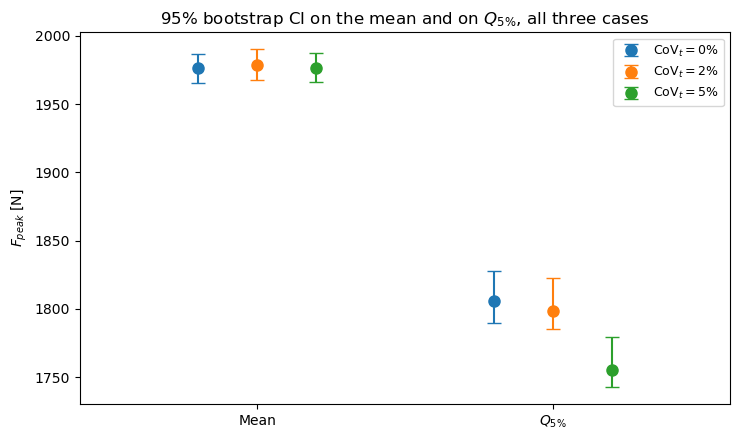

  CoV_t  stat            95% CI [N]  overlap vs. baseline [N]
-------------------------------------------------------------
     0%  mean    [ 1965.41,  1986.78]                     21.37
     2%  mean    [ 1967.90,  1990.23]                     18.88
     5%  mean    [ 1966.20,  1987.10]                     20.57
     0%    q5    [ 1789.86,  1827.48]                     37.62
     2%    q5    [ 1785.52,  1822.98]                     33.12
     5%    q5    [ 1742.85,  1779.83]                    -10.03


In [ ]:
# Reuse bootstrap_ci for two different statistics: the mean (mean_fn) and the order-statistic
# Q5% (q5_fn) -- NB3's own pair, imported from bootstrap.py rather than redefined.
mean_fn = lambda a, axis: a.mean(axis=axis)
q5_fn = lambda a, axis: np.percentile(a, 5, axis=axis)

CI_SEED = {0.0: 201, 0.02: 202, 0.05: 203}   # one bootstrap generator per case, distinct from Part 3's

# One bootstrap CI per (case, statistic) combination -- six in total.
ci = {}
for cov_t in COV_T_CASES:
    f = results[cov_t]["f"]
    rng = np.random.default_rng(CI_SEED[cov_t])
    ci[cov_t] = dict(mean=bootstrap_ci(f, mean_fn, rng=rng),
                     q5=bootstrap_ci(f, q5_fn, rng=rng))

# All six estimates are forces in N and of comparable magnitude, so they share one axis: two
# x-groups (Mean, Q5%), each holding one marker per case, offset sideways so they don't overlap.
OFFSET = {0.0: -0.2, 0.02: 0.0, 0.05: 0.2}
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for cov_t in COV_T_CASES:
    for x0, stat in ((0, "mean"), (1, "q5")):
        res = ci[cov_t][stat]
        ax.errorbar([x0 + OFFSET[cov_t]], [res["estimate"]],
                    yerr=[[res["estimate"] - res["ci_low"]], [res["ci_high"] - res["estimate"]]],
                    fmt="o", color=CASE_COLOR[cov_t], ms=8, capsize=5,
                    label=rf"$\mathrm{{CoV}}_t={cov_t*100:.0f}\%$" if stat == "mean" else None)

ax.set_xticks([0, 1])
ax.set_xticklabels(["Mean", "$Q_{5\\%}$"])
ax.set_xlim(-0.6, 1.6)
ax.set_ylabel("$F_{peak}$ [N]")
ax.set_title("95% bootstrap CI on the mean and on $Q_{5\\%}$, all three cases")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

# The overlap between each case's interval and the CoV_t=0 baseline's, computed rather than
# eyeballed. A positive number is how much the two intervals overlap; a negative number is the
# gap between them -- and a negative number is what "resolvable" means here.
print(f"{'CoV_t':>7}{'stat':>6}{'95% CI [N]':>22}{'overlap vs. CoV_t=0 baseline [N] ':>26}")
print("-" * 63)
for stat in ("mean", "q5"):
    base = ci[0.0][stat]
    for cov_t in COV_T_CASES:
        res = ci[cov_t][stat]
        overlap = min(base["ci_high"], res["ci_high"]) - max(base["ci_low"], res["ci_low"])
        print(f"{cov_t:7.0%}{stat:>6}    [{res['ci_low']:8.2f}, {res['ci_high']:8.2f}]{overlap:26.2f}")

*(Read the printed overlap column against the baseline before the Discussion below: a positive
number means the two intervals genuinely overlap and the apparent shift is not distinguishable
from sampling noise at this $N$; a negative number is a real gap between them.)*

### Discussion

**The mean barely moves.** The three converged means agree to about a tenth of a percent, and
their 95% bootstrap intervals overlap heavily in the error-bar figure above. This is Part 1,
Step 1 made visible: because $t$ enters $F_{peak}=w\,t\,X_T$ multiplicatively about
a fixed mean $t_0$, the expectation factorises to $w\,t_0\,\mu_X$ no matter how much $t$
scatters. Any input that enters multiplicatively about a fixed mean leaves the output's mean
alone, in any model; what this particular map adds is that the statement is *exact* here
rather than a first-order approximation, because the product's mean needs no linearisation.

**The spread grows exactly as Part 1 predicted.** The empirical output CoVs
($\approx 5.1\%,\ 5.4\%,\ 7.1\%$) sit on the exact values from the boxed identity
($5.00\%,\ 5.39\%,\ 7.08\%$), the small excess being this particular draw's own sampling
scatter. All of the second input's effect is here, in the width.

**The low-percentile design value moves left.** $\widehat Q_{5\%}$ goes from $\approx 1806$ N
at $\mathrm{CoV}_t=0$ to $\approx 1798$ N at $2\%$ (a $-0.4\%$ shift) to $\approx 1755$ N at
$5\%$ (a $-2.8\%$ shift). The error-bar figure's overlap column says which of these two shifts
is bigger than the campaigns' own sampling noise: the $\mathrm{CoV}_t=5\%$ interval separates
cleanly from the baseline's, while the $2\%$ interval still overlaps it. This is consistent with
$2\%$ being a genuinely small addition of scatter on top of $X_T$'s own $5\%$. The mean did not
move; the tail did. The mechanism is completely general and worth stating on its own: a wider
distribution with the same centre has a lower 5th percentile, so a design allowable is punished
by scatter even when the average part is unchanged. This is NB2's "the mean is the wrong number
to design against," arrived at here by adding an uncertain input rather than by targeting a
deeper percentile.

**The cost result.** The converged sample sizes are $N = 370,\ 380,\ 700$. Going from one uncertain input to two, at $\mathrm{CoV}_t=2\%$, cost **10 extra samples**, a $+2.7\%$ change. Then keeping the input count fixed at two and raising that same input's scatter to $5\%$ **nearly doubled** $N$. The measured ratios relative to the baseline are $1.00,\ 1.03,\ 1.89$, against Part 2's predicted $1.00,\ 1.16,\ 2.00$. The $N \propto \mathrm{CoV}_F^{\,2}$ scaling holds, and the difference between the measured and predicted ratios can be attributed both to the approximation of the scaling and to the usual Monte Carlo scatter on a few hundred samples.

## Conclusion

This notebook added a second uncertain input, ply thickness $t$, to the
single-element peak-force model and worked entirely from the small-strain map
$F_{peak}=w\,t\,X_T$.

**What this notebook established:**

- **Marginal, joint, covariance, independence.** Two uncertain inputs are described by a
  joint distribution, not just by their two marginals; covariance (and its normalised form,
  the correlation coefficient) measures whether the two scatter *together*; and independence
  &ndash; zero covariance built in by construction, from two separately seeded draws &ndash;
  is the extra assumption that makes the marginals sufficient and that the exact variance
  result below needs.
- **One thing stays exactly computable: the output's CoV.** Deriving
  $\mathrm{Var}(t\,X_T)$ for independent $t, X_T$ from first principles gives
  $\mathrm{CoV}_F^2 = \mathrm{CoV}_t^2 + \mathrm{CoV}_{X_T}^2 +
  \mathrm{CoV}_t^2\mathrm{CoV}_{X_T}^2$, a quadrature
  combination plus a cross term that is negligible at these CoVs. The derivation uses only the
  multiplicative map, independence and finite variance, so it would hold for non-Normal inputs
  just as well. The product's *full* distribution, by contrast, has no *elementary* closed
  form: its exact density exists, but only as an infinite series of Bessel functions, with no closed-form percentile to invert.
- **Why $N$ tracks scatter, not input count.** The asymptotic standard error of a sample
  quantile, $SE(\widehat Q_p) = \sqrt{p(1-p)/N}\,/\,f(Q_p)$, needs only
  a continuous output with positive density at $Q_p$, no distributional family. Combined with
  $f(Q_p)\propto 1/\sigma_F$ (a density integrates to 1, so stretching a distribution shrinks
  its height everywhere in proportion) it gives $N \propto \mathrm{CoV}_F^{\,2}$ at fixed
  relative precision, an expression in which the input count never appears &ndash; the same
  $\mathrm{relSE}\propto\mathrm{CoV}/\sqrt N$ structure NB2 met for the mean.
- **Three campaigns, NB3's criterion unchanged.** At $\mathrm{CoV}_t\in\{0,\ 2\%,\ 5\%\}$ the
  bootstrap-monitored $N$ came out $370,\ 380,\ 700$. One input to two: $+10$ samples. Two inputs, more scatter on one: nearly double.
- **What a second uncertain input does to the output &ndash; and whether that's resolvable.**
  The mean is untouched (its bootstrap intervals overlap heavily), because $t$ enters
  multiplicatively about a fixed mean; the spread grows by the quadrature identity; and the
  5th-percentile design value moves left ($-0.4\%$ then $-2.8\%$) purely because the
  distribution widened, and the error-bar comparison shows the larger of those two shifts is a real, resolvable gap, distinguishable from sampling noise at this $N$.

**Where this goes next.** Everything here rested on being able to *read* $F_{peak}$'s exact
algebraic form: to know that only $t$ and $X_T$ matter, since nothing else is an argument of
the function, and to combine their scatter by hand into $\mathrm{CoV}_F$. A real numerical
model has no such formula to inspect, and no way to tell by looking which of its many inputs actually drive the output.
NB5 introduces a **number** for exactly that: "how much of the output's variance does input
$i$ explain," which needs no closed form. It defines and estimates global **Sobol' indices**, derived from first principles and computed both in closed form (where this series' own maps allow it) and by a general-purpose Monte Carlo estimator that needs no closed form at all. We will see that the estimation of the Sobol' indices has a cost of $\sim N(d+2)$ model runs for $d$ inputs which, unlike the plain mean or percentile estimates of these first four notebooks, genuinely *does* grow with the number of inputs.